## This is a sample Machine Learning project that exemplifies how to proceed Linear Regression Analysis, using Python, Pandas, NumPy, SciPy, Statsmodels, Statstests, Pingouin, Scikit-learn, Matplotlib, Seaborn and Plotly, along with Anaconda managed environments

In [1]:
!pip install --upgrade statstests # gotta install statstests through pip - not available at conda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("dark_background")
import matplotlib.cm as cm
from sklearn.preprocessing import LabelEncoder
from scipy.stats import pearsonr
from scipy.stats import boxcox
from scipy.stats import norm
from scipy import stats
from scipy.optimize import curve_fit
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from statstests.process import stepwise
from statstests.tests import shapiro_francia
from statstests.process import stepwise
import networkx as nx
import pingouin as pg
import seaborn as sns
import plotly.graph_objects as go
import os
import plotly.io as pio
if os.getenv("GITHUB_ACTIONS") == "true":
    pio.renderers.default = "png"
else:
    pio.renderers.default='colab'
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

- the formulas shown at this notebook have been taken from the following reference:

    FÁVERO, L. P.; BELFIORE, P. Manual de Análise de Dados: Estatística e Machine Learning com Excel®, SPSS®, Stata®, R® e Python®. 2ª edição, 1288 p. Brasil: ccGEN LTC, 2024.
    
    Available in Brazil at:
    
    https://www.amazon.com.br/Manual-An-C3-A1lise-Dados-Estat-C3-ADstica-Learning-dp-8595159920/dp/8595159920

## Use Case Scenario and Data - height = f(age). Simple Linear Regression with Box-Cox normalization.

This is another use-case for Generalized Linear Models (GLMs), in this case, of type Simple Linear Regression (SLR). Here, we show a simple regression of babies' height from babies' age, being the height the dependent variable and the age the explicative variable, both quantitative (no dummyzation necessary). The focus of this example is to show how to check if the residuals or errors (Ŷ-Y) of the model are normalized, i.e., if the ahderence of residuals (of observations) to the Normal distrubtion actually exists. It's essential that the residuals are normalized, so that the hypothesis tests F and t Student of the model and params are valid, and, therefore, the significance of the regression model, specifically for OLS regression, as well. So, in this project, we basically show how to use an algorithm - Shapiro-Francia (one of many available) - to calculate that normalization of residuals, and, in case these are not normalized, how to try to normalize them using the Box-Cox normalization method, which generally fixes the problem. If the normalization is not possible, the model, for those variables, is statistically invalid. For other advanced linear regression analysis topics, including dummyzation of qualitative variables, multicollinearity and heteroscedasticity diagnostics, and stepwise method, check out other examples at this same project directory.

In [2]:
# reading and displaying our dataset
# height is in cm, age is in months
babies_df = pd.read_csv('babies.csv', delimiter=',', encoding="utf-8")
babies_df

,height,age
0,63.07,19.00
1,65.63,21.00
2,65.63,22.50
3,66.73,22.50
4,66.37,23.25
...,...,...
69,75.90,30.50
70,78.47,31.00
71,80.67,36.50
72,81.03,38.00


In [3]:
babies_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   height  74 non-null     float64
 1   age     74 non-null     float64
dtypes: float64(2)
memory usage: 1.3 KB


In [4]:
babies_df.describe()

,height,age
count,74.000000,74.000000
mean,66.921622,25.312162
std,12.852386,12.975168
min,31.900000,2.150000
25%,56.470000,12.500000
50%,70.400000,26.000000
75%,75.807500,33.000000
max,87.630000,60.000000


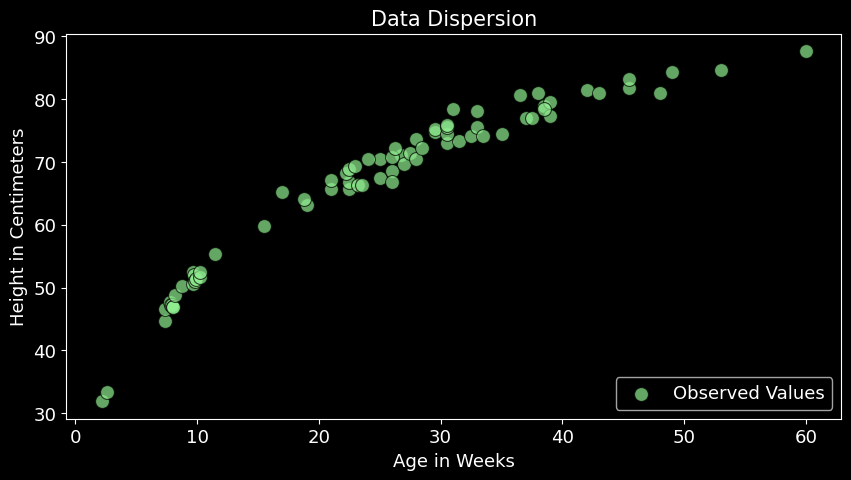

In [5]:
# creating a dispersion graph with the dataset (no regression model yet - no fitted values, only observed values)

plt.figure(figsize=(10,5))
sns.scatterplot(x="age", y="height", data=babies_df, color='lightgreen', edgecolor='black',
                s=100, label='Observed Values', alpha=0.7)
plt.title('Data Dispersion', fontsize=15)
plt.xlabel('Age in Weeks', fontsize=13)
plt.ylabel('Height in Centimeters', fontsize=13)
plt.legend(loc='lower right', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.show()

In [6]:
# defining a linear model for height explained by age:

babies_linear_model = sm.OLS.from_formula('height ~ age', babies_df).fit()
babies_linear_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 height   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     667.7
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           3.72e-38
Time:                        14:13:05   Log-Likelihood:                -207.26
No. Observations:                  74   AIC:                             418.5
Df Residuals:                      72   BIC:                             423.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     43.1004      1.034     41.665      0.000      41.038      45.163
age            0.9411      0.036     25.841      0.000       0.868       1.014
==============================================================================
Omnibus:                       21.203   Durbin-Watson:                   0.278
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               29.159
Skew:                          -1.218   Prob(JB):                     4.66e-07
Kurtosis:                       4.877   Cond. No.                         62.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
# mounting the model equation
params = babies_linear_model.params

# printing the params
print(f'alfa (intercept) = {params["Intercept"]}\nbeta (age) = {params["age"]}\n')

# # printing the regression equation
terms = [f"{coef:.4f}*{name}" for name, coef in params.items() if name != "Intercept"]
equation = f"height = {params['Intercept']:.4f} + " + " + ".join(terms)
print(equation)

alfa (intercept) = 43.10040260545884
beta (age) = 0.9410977562308716

height = 43.1004 + 0.9411*age


In [8]:
# adding fitted values (Y'i), from the linear model above, to the dataset (at the same magnitude of the original observed data):
babies_df["height_linear"] = babies_linear_model.fittedvalues
babies_df

,height,age,height_linear
0,63.07,19.00,60.981260
1,65.63,21.00,62.863455
2,65.63,22.50,64.275102
3,66.73,22.50,64.275102
4,66.37,23.25,64.980925
...,...,...,...
69,75.90,30.50,71.803884
70,78.47,31.00,72.274433
71,80.67,36.50,77.450471
72,81.03,38.00,78.862117


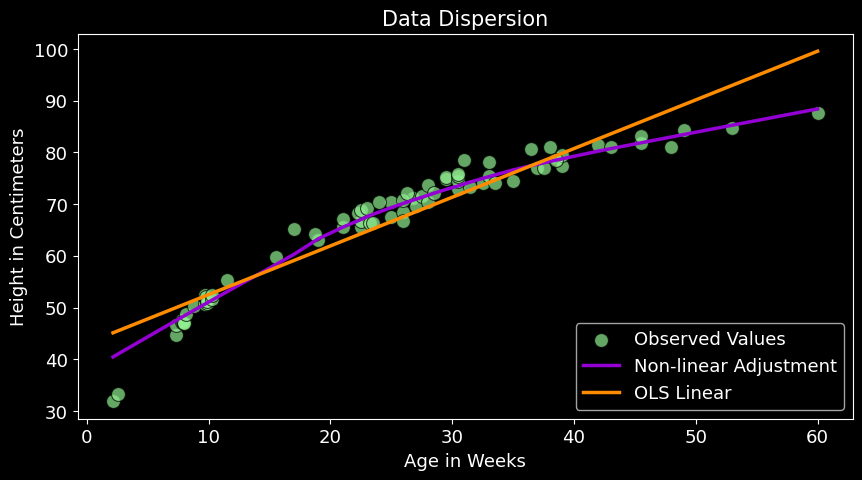

In [9]:
# creating a dispersion graph, with the observed values and with the linear and non-linear ('lowess=True' - locally weighted 
# scatterplot smoothing) fitted values, based on the model above. Observe that, even if the linear model above looks pretty fine
# in terms of F and t p-values, there seems to be a better non-linear regression model that represents better the observed 
# values, with lower residuals, when fitting them to a prediction line (a curved line, not a linear one). That's typical of 
# nonlinear phenomena, as the babies' height, according to the babies' age, in this case

plt.figure(figsize=(10,5))
sns.scatterplot(x="age", y="height", data=babies_df, color='lightgreen', edgecolor='black',
                s=100, label='Observed Values', alpha=0.7)
sns.regplot(x="age", y="height", data=babies_df, lowess=True,
            color='darkviolet', ci=False, scatter=False,
            label='Non-linear Adjustment',
            line_kws={'linewidth': 2.5})
sns.regplot(x="age", y="height", data=babies_df,
            color='darkorange', ci=False, scatter=False,
            label='OLS Linear',
            line_kws={'linewidth': 2.5})
plt.title('Data Dispersion', fontsize=15)
plt.xlabel('Age in Weeks', fontsize=13)
plt.ylabel('Height in Centimeters', fontsize=13)
plt.legend(loc='lower right', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.show()

In [10]:
# At OLS regression models, we should always check the normality of residuals, i.e., the adherence of residuals (of observations)
# to the Normal distribution. The adherence means that there's no statistical difference between the residuals and the normal 
# distribution values, and that, therefore, H0 is NOT rejected (p-value > alfa). That means the distribution of residuals is 
# statistically equal to the distribution of the Normal curve. And that's what is expected, so that our model have statistics 
# correctly calculated, for the model itself (F) and its individual regression parameters (t). In case the H0 is rejected (p-value 
# < alfa), when comparing the residuals to the Normal distribution, that means the residuals are not normalized, and some method 
# should be tried to normalize them into a new curve (with different params) more compatible to the Normal distribution. If that 
# normalization succeeds, we may use this new normalized model to predict the dependent variable's values, not forgetting to 
# transfom them back to the original magnitude. When using normalized models, the predicted values are NOT the final values we're 
# looking for, and, on each prediction result, they must be transformed back to the original magnitude. But, at least, that turns 
# possible a normalilzed model to be used, with the residuals adherent to the Normal curve. There are methods, as Shapiro-Francia, 
# to check if the residuals are normalilzed, and there are methodologies, as Box-Cox, to try to normalize them. Eventually, the 
# caos in the values of residuals is so big, that it is actually impossible to proceed the normalization anyway. In such a case, 
# we should reassess the variables and data of the model (including sample size), so that new datasets can be tried... with a 
# lower variance on the residuals.

![./shapiro-francia.png](./shapiro-francia.png)

In [11]:
# testing adherence of residuals to normality through the shapiro-francia method:

sf_test = shapiro_francia(babies_linear_model.resid)
sf_test = sf_test.items()
method, statistics_W, statistics_z, p = sf_test
print('Statistics W=%.5f, p-value=%.6f' % (statistics_W[1], p[1]))
alpha = 0.05 # significance level desired
if p[1] > alpha:
	print('H0 not rejected - residuals adherent to normality')
else:
	print('H0 rejected - residuals NOT adherent to normality')

# as we can see below, for a significance level of 5%, or 95% confidance level, H0 is rejected, p<<<0.05, and therefore the 
# residuals are statistically different from the Normal, thus NOT adherent to its distribution. We must try normalizing the 
# residuals curve, for ex., by using Box-Cox method. And then reassess the normalization of the residuals with shapiro-francia.

method  :  Shapiro-Francia normality test
statistics W  :  0.9087044262594459
statistics z  :  3.6276504915453778
p-value  :  0.0001430060355543775
Statistics W=0.90870, p-value=0.000143
H0 rejected - residuals NOT adherent to normality


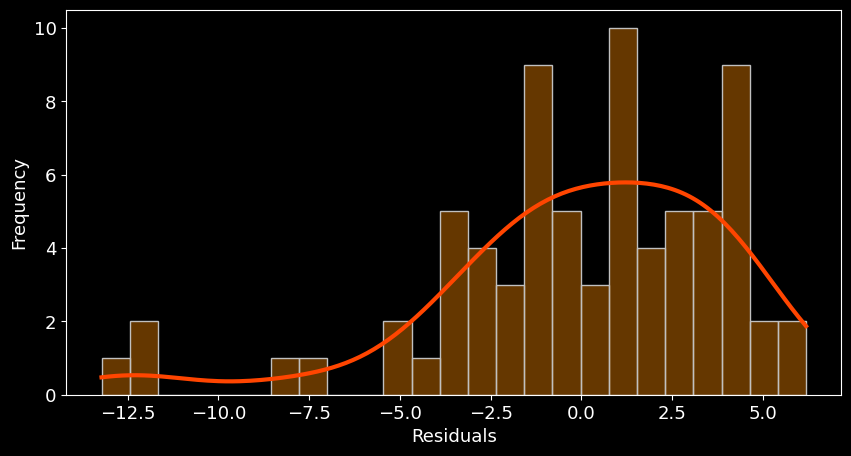

In [12]:
# Below, you have the NOT normalized residuals curve from our linear regression model above
# Observe that residuals variance is visually too big for the residuals curve to be statistically equal to the Normal curve
# We must use a normalization method (e.g. Box-Cox) to try to normalize the residuals to the Normal curve, before we can use
# the normalized model to make significant dependent variable predictions

plt.figure(figsize=(10,5))
hist1 = sns.histplot(data=babies_linear_model.resid, kde=True, bins=25,
                     color = 'darkorange', alpha=0.4, edgecolor='silver',
                     line_kws={'linewidth': 3})
hist1.get_lines()[0].set_color('orangered')
plt.xlabel('Residuals', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.show()

![./box-cox.png](./box-cox.png)

In [13]:
# Proceeding Box-Cox transformation or normalization (IT IS NOT A STANDARDIZATION !)
# For doing that through the method below, from scipy.stats, just pass the df and the Y name, and you'll have the Y* values
# (for each observation) and the lambda value of the transformation. You then use that to define the box-cox normalized model. 
# Both Y and Y* are observed values, either in original or in box-cox magnitudes. None of them are fitted values (Yhat or Ŷ) yet.

# After we define a box-cox model based on the observed values above, we will have available the fitted values (Ŷ*) for that 
# model at box-cox magnitude. We do any regressions on the model respecting that box-cox magnitude. But, after we get each 
# pedicted value from the box-cox model, we gotta transform these results back to the original magnitude of the corresponding Ŷi. 
# Final regression results should NEVER be expressed as Ŷ*i, without being first transformed to the original Ŷ magnitude. The 
# transformation correspodence between Y and Y*, and, then, from Ŷ* to Ŷ, is the calculated lambda below. You may check out the 
# Y* values below by calculating manually these values according to the Y* formula at the image above.
yast, lmbda = boxcox(babies_df['height'])

print(f"Box-Cox calculated lambda is: {lmbda}")

# adding yast (Y*i) to our dataset df:
babies_df["height_box_cox"] = yast
babies_df

Box-Cox calculated lambda is: 2.659051117199506


,height,age,height_linear,height_box_cox
0,63.07,19.00,60.981260,22966.092606
1,65.63,21.00,62.863455,25529.075884
2,65.63,22.50,64.275102,25529.075884
3,66.73,22.50,64.275102,26682.733457
4,66.37,23.25,64.980925,26301.668594
...,...,...,...,...
69,75.90,30.50,71.803884,37577.506812
70,78.47,31.00,72.274433,41056.620650
71,80.67,36.50,77.450471,44189.027404
72,81.03,38.00,78.862117,44715.337339


In [14]:
# defining a new model for height* explained by age, using now the box-cox transformed values (Y*i) instead of the original Yi. 
# Hopefully, this new model will have normalized residuals, so that we can use it as a valid and significant regression model. This
# new model, though, is a non-linear one (power specification), as lambda is different from 1 (see picture above with examples of
# possible lambda specifications). Actually, this model lies between a quadratic and a cubic models.

# Observe we now pass the height_box_cox column as Y* (observed values in box-cox magnitude) and the same age column as 
# explicative variable, from the babies_df:
babies_non_linear_model = sm.OLS.from_formula('height_box_cox ~ age', babies_df).fit()
babies_non_linear_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         height_box_cox   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.961
Method:                 Least Squares   F-statistic:                     1822.
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           7.16e-53
Time:                        14:13:06   Log-Likelihood:                -681.77
No. Observations:                  74   AIC:                             1368.
Df Residuals:                      72   BIC:                             1372.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4995.1615    630.253      7.926      0.000    3738.775    6251.548
age          947.2302     22.189     42.689      0.000     902.997     991.463
==============================================================================
Omnibus:                        1.140   Durbin-Watson:                   0.813
Prob(Omnibus):                  0.566   Jarque-Bera (JB):                0.557
Skew:                           0.098   Prob(JB):                        0.757
Kurtosis:                       3.377   Cond. No.                         62.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:
# mounting the model equation
params = babies_non_linear_model.params

# printing the params
print(f'alfa* (intercept) = {params["Intercept"]}\nbeta* (age) = {params["age"]}\n')

# printing the regression equation
terms = [f"{coef:.4f}*{name}" for name, coef in params.items() if name != "Intercept"]
equation = f"height* = {params['Intercept']:.4f} + " + " + ".join(terms)
print(equation)

alfa* (intercept) = 4995.161504684529
beta* (age) = 947.2302321089381

height* = 4995.1615 + 947.2302*age


In [16]:
# adding fitted values, from our non-linear model (box-cox model), already transformed from Ŷ* to Ŷ magnitudes, to our dataset:
babies_df["height_non_linear_transf"] = (babies_non_linear_model.fittedvalues * lmbda + 1) ** (1 / lmbda)
babies_df

,height,age,height_linear,height_box_cox,height_non_linear_transf
0,63.07,19.00,60.981260,22966.092606,63.097300
1,65.63,21.00,62.863455,25529.075884,65.004303
2,65.63,22.50,64.275102,25529.075884,66.375858
3,66.73,22.50,64.275102,26682.733457,66.375858
4,66.37,23.25,64.980925,26301.668594,67.044337
...,...,...,...,...,...
69,75.90,30.50,71.803884,37577.506812,73.004869
70,78.47,31.00,72.274433,41056.620650,73.386942
71,80.67,36.50,77.450471,44189.027404,77.388462
72,81.03,38.00,78.862117,44715.337339,78.422026


In [17]:
# another way of indirectly comparing the linear and box-cox models:
summary_col([babies_linear_model, babies_non_linear_model],
            model_names=["Linear Model","Box-Cox Model"],
            stars=True,
            info_dict = {
                'N':lambda x: "{0:d}".format(int(x.nobs))
        })

,Linear Model,Box-Cox Model
Intercept,43.1004***,4995.1615***
,(1.0345),(630.2530)
age,0.9411***,947.2302***
,(0.0364),(22.1889)
R-squared,0.9027,0.9620
R-squared Adj.,0.9013,0.9615
N,74,74


In [18]:
# comparing R2 between linear and box-cox models
pd.DataFrame({'R² OLS':[round(babies_linear_model.rsquared,4)],
              'R² Box-Cox':[round(babies_non_linear_model.rsquared,4)]})

,R² OLS,R² Box-Cox
0,0.9027,0.962


In [19]:
# Our Box-Cox new model, from Y*i instead of Yi, has incresed R2 significantly and kept significant F and t tests for all 
# regression params. These params, including alfa and betas, though, are not directly comparable with the later model, as they're
# different in magnitude.

# We just have now to re-check if the residuals are finally adherent to the Normal, by re-running the shapiro-francia test on this 
# current model. If they are, we can use this box-cox model for regressions, as long as we transform each Ŷ*i back to Ŷi, before 
# returning them as final results.

In [20]:
sf_test = shapiro_francia(babies_non_linear_model.resid)
sf_test = sf_test.items()
method, statistics_W, statistics_z, p = sf_test
print('Statistics W=%.5f, p-value=%.6f' % (statistics_W[1], p[1]))
alpha = 0.05 # significance level desired
if p[1] > alpha:
	print('H0 not rejected - residuals adherent to normality')
else:
	print('H0 rejected - residuals NOT adherent to normality')

# thankfully, we succeeded in normalizing the residuals from the linear model by creating another model through Box-Cox 
# transformation, and this box-cox, not only has the residuals normalized, but F and t tests for params significant. We can
# therefore use it to do our regression predictions, and later transform the results (Ŷ*i) back to Ŷi original magnitude.

# observe that p (0.10) >>> alfa (0.05), therefore we do NOT reject H0 anymore, which means that our residuals are statistically
# equal to the Normal, and, therefore, normalized.

method  :  Shapiro-Francia normality test
statistics W  :  0.9729952064687977
statistics z  :  1.2666154523890727
p-value  :  0.10264641223384502
Statistics W=0.97300, p-value=0.102646
H0 not rejected - residuals adherent to normality


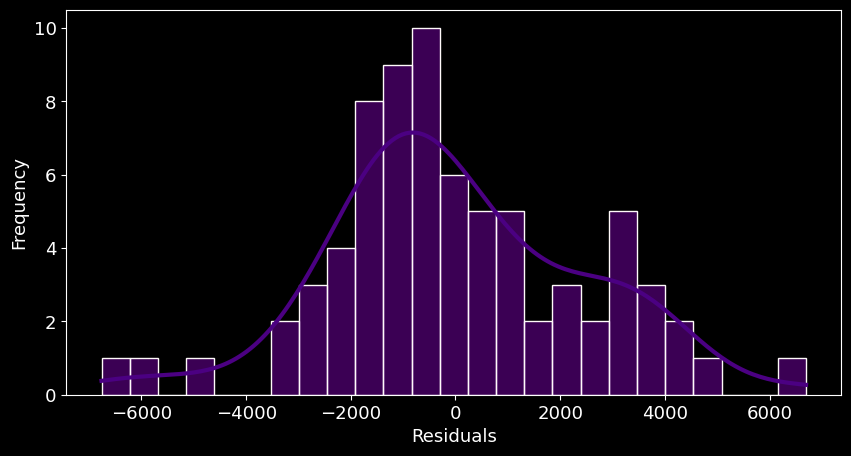

In [21]:
plt.figure(figsize=(10,5))
hist1 = sns.histplot(data=babies_non_linear_model.resid, kde=True, bins=25,
                     color = 'darkviolet', alpha=0.4, edgecolor='snow',
                     line_kws={'linewidth': 3})
hist1.get_lines()[0].set_color('indigo')
plt.xlabel('Residuals', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.show()

# observe that now the variance of the residuals are much less erratic, and follows better the Normal curve. They're now normalized.

In [22]:
# Doing some predictions on the box-cox model:
# - what's the height expected for a baby of 52 weeks ?

# using original linear model fitted values (Ŷi) (with residuals not normalized !)
print(f"Original linear model: height for age=52 weeks is {round(babies_linear_model.predict(pd.DataFrame({'age':[52]}))[0],2)}cm")

# using box-cox non-linear model fitted values (Ŷ*i) (with residuals normalized !). Gotta transform the result back from Ŷ*i to Ŷi.
print(f"Box-Cox non-linear normalized model: height* for age=52 weeks is {round(babies_non_linear_model.predict(pd.DataFrame({'age':[52]}))[0],2)}cm")

# transforming the Ŷ*i (height*) above to Ŷi (height), by using the inverse of the Y* formula at the formulas image up above. As 
# we once transformed the Yi to Y*i, now we're transforming Ŷ*i regression result to Ŷi... as only Ŷi has a meaning on the real 
# world.
print(f"Box-Cox non-linear normalized model: height (transformed back) for age=52 weeks is {round((54251.13357434931 * lmbda + 1) ** (1 / lmbda),2)}cm")

# Observe the 5.3% lower fitted (expected) value for the height of babies when having the prediction done on a model with a
# normalized residual, rather than on a model with residuals non-adherent to the Normal. The more accurate fitted (reference)
# values can make total difference on diagnostics and therapeutic decisions performed by the multi-professional and 
# multi-disciplinar clinical team. So we should always work with OLS regression models whose residuals do adhere to the 
# Normal.

Original linear model: height for age=52 weeks is 92.04cm
Box-Cox non-linear normalized model: height* for age=52 weeks is 54251.13cm
Box-Cox non-linear normalized model: height (transformed back) for age=52 weeks is 87.14cm


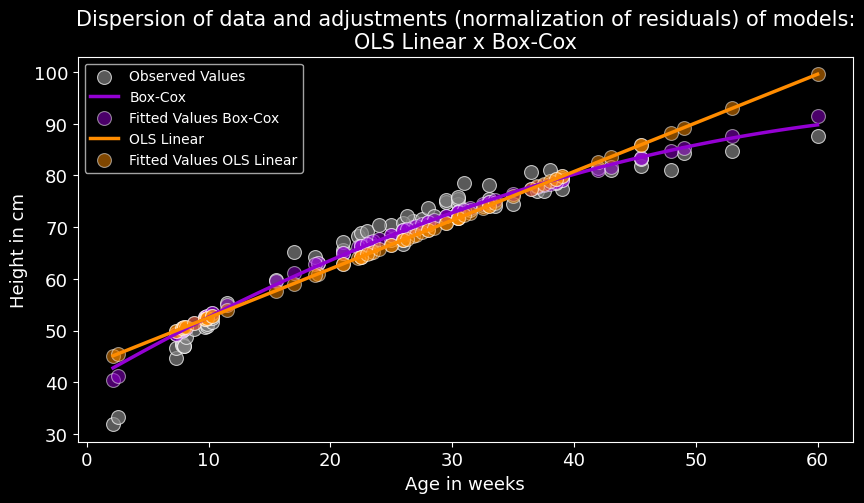

In [23]:
# plotting a graph for comparing:
# - the observed values (Yi), in their original magnitude
# - the fitted values (Ŷi), from the non-linear box-cox model, already transformed from Ŷ* to Ŷ - same magnitude of original 
# observed data
# - the fitted values (Ŷi), from the linear model - also at the same magnitude of original observed data, already

plt.figure(figsize=(10,5))
sns.scatterplot(x="age", y="height", data=babies_df, color='grey',
                s=100, label='Observed Values', alpha=0.7)
sns.regplot(x="age", y="height_non_linear_transf", data=babies_df, order=lmbda,
            color='darkviolet', ci=False, scatter=False, label='Box-Cox',
            line_kws={'linewidth': 2.5})
sns.scatterplot(x="age", y="height_non_linear_transf", data=babies_df, color='darkviolet',
                s=100, label='Fitted Values Box-Cox', alpha=0.5)
sns.regplot(x="age", y="height_linear", data=babies_df,
            color='darkorange', ci=False, scatter=False, label='OLS Linear',
            line_kws={'linewidth': 2.5})
sns.scatterplot(x="age", y="height_linear", data=babies_df, color='darkorange',
                s=100, label='Fitted Values OLS Linear', alpha=0.5)
plt.title('Dispersion of data and adjustments (normalization of residuals) of models:\nOLS Linear x Box-Cox',
          fontsize=15)
plt.xlabel('Age in weeks', fontsize=13)
plt.ylabel('Height in cm', fontsize=13)
plt.legend(loc='upper left', fontsize=10)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.show()

In [24]:
# Observe, at the graph above, the difference we have on the different fitted values, between a linear model, with no normalized 
# residuals, and a non-linear box-cox model, with normalized residuals. Depending on the use-case, such a difference can be 
# critical. The non-linear box-cox regression model is much better and should be used instead. Observe that we plotted the values 
# of Ŷ*i already transformed to Ŷi, as Ŷ* magnitude would be too discrepant for any comparison with the linear model Ŷ magnitude, 
# or with the observed Y values.

In [25]:
# Or, a more iteractive graph (lambda = 2.659051008426254):

coefficients = np.polyfit(babies_df["age"], babies_df["height_non_linear_transf"], lmbda)
x_range = np.linspace(babies_df["age"].min(), babies_df["age"].max(), 100)
y_quadratic = np.polyval(coefficients, x_range)

fig = go.Figure()

fig.add_trace(go.Scatter(x=babies_df["age"], y=babies_df["height"],
                         mode='markers',
                         marker=dict(color='grey', opacity=0.7, size=20),
                         name='Observed Values'))

fig.add_trace(go.Scatter(x=x_range, y=y_quadratic,
                         mode='lines',
                         line=dict(color='darkviolet', width=2),
                         name='Box-Cox'))

fig.add_trace(go.Scatter(x=babies_df["age"], y=babies_df["height_non_linear_transf"],
                         mode='markers',
                         marker=dict(color='darkviolet', opacity=0.5, size=15),
                         name='Fitted Values Box-Cox',
                         hovertemplate='Fitted Values Box-Cox: %{y:.2f}<extra></extra>'))

fig.add_trace(go.Scatter(x=babies_df["age"], y=babies_df["height_linear"],
                         mode='lines',
                         marker=dict(color='darkorange'),
                         name='OLS Linear',
                         hovertemplate='Fitted Values OLS Linear: %{y:.2f}<extra></extra>'))

fig.add_trace(go.Scatter(x=babies_df["age"], y=babies_df["height_linear"],
                         mode='markers',
                         marker=dict(color='darkorange', opacity=0.5, size=15),
                         name='Fitted Values OLS Linear',
                         hovertemplate='Fitted Values OLS Linear: %{y:.2f}<extra></extra>'))

fig.update_layout(title={
        'text': 'Dispersion of data and adjustments (normalization of residuals) of models:\nOLS Linear x Box-Cox',
        'font': {'size': 15, 'color': 'black', 'family': 'Arial'},
        'x': 0.5,
        'y': 0.95,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    xaxis_title='Age in Weeks',
    yaxis_title='Height in Centimeters',
    legend=dict(x=1.02, y=1),
    template='plotly_white')

fig.update_annotations(dict(xref="x", yref="y"))
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')

fig.show()